# EquiRelief — Week 3: RL Training

## MDP Formulation
- **State** per region i: `[need_food, need_water, need_medicine, resource, wait, ratio, urgency]` + global `fairness` scalar
- **Actions**: Send food / water / medicine to region i, or Wait → `3×N + 1 = 16` actions for N=5 regions
- **Reward**: `α·EfficiencyGain − λ·Var(ratios) + β·urgency_bonus − δ·delay_penalty`
- **γ** (discount) = 0.99

## Four RL enhancements
| Problem | Enhancement |
|---|---|
| State space too large for Q-table | Deep Q-Network (DQN) |
| Overestimates Q-values | Double DQN (separate select + eval networks) |
| Rare emergencies underrepresented | Prioritized Experience Replay (PER) |
| Fairness effects delayed | n-Step TD returns |

## Policies compared
1. **Random** — uniform random action
2. **Greedy** — always serve region with highest total need
3. **EquiRelief** — Double DQN + PER + n-step TD

**Runtime**: GPU recommended but not required. RL training runs on CPU in ~15 min.

## Cell 1 — Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = '/content/drive/MyDrive/Equi-Relief'
if f'{BASE}/notebooks' not in sys.path:
    sys.path.insert(0, f'{BASE}/notebooks')

import config, utils
utils.set_seed(config.SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Regions: {config.REGIONS}')
print(f'N      : {config.N_REGIONS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
Regions: ['north', 'south', 'east', 'west', 'central']
N      : 5


In [3]:
%%capture
!pip install -q gymnasium numpy pandas matplotlib seaborn torch
print('Done.')

In [4]:
import json, random, math, copy, time, warnings
from collections import deque, namedtuple
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import spaces

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2']

def section(t):
    print('\n' + '='*60)
    print(f'  {t}')
    print('='*60)

def savefig(name):
    p = f'{config.OUT_PLOTS}/{name}.png'
    plt.savefig(p, bbox_inches='tight', dpi=150)
    print(f'  saved -> {p}')

print('Imports OK.')

Imports OK.


---
# Part 1 — Load Demand Vector from NLP Pipeline

In [5]:
section('Load region_demand.json from Week 2')

demand_path = f'{config.OUT_DEMAND}/region_demand.json'
demand_raw  = utils.load_json(demand_path)

REGIONS = config.REGIONS   # ['north','south','east','west','central']
N       = config.N_REGIONS # 5

print('Demand vector loaded:')
print(f'{"Region":<10} {"Food":>6} {"Water":>6} {"Medicine":>9} {"Urgency":>8} {"Messages":>9}')
print('-'*52)
for region in REGIONS:
    d = demand_raw[region]
    n = d['need']
    print(f'{region:<10} {n["food"]:>6} {n["water"]:>6} {n["medicine"]:>9} {d["urgency"]:>8.2f} {d["message_count"]:>9}')

# Convert to numpy arrays for RL environment
# need[i] = total resource demand for region i (food+water+medicine combined)
need_food     = np.array([demand_raw[r]['need']['food']     for r in REGIONS], dtype=np.float32)
need_water    = np.array([demand_raw[r]['need']['water']    for r in REGIONS], dtype=np.float32)
need_medicine = np.array([demand_raw[r]['need']['medicine'] for r in REGIONS], dtype=np.float32)
urgency_init  = np.array([demand_raw[r]['urgency']          for r in REGIONS], dtype=np.float32)

# Normalise needs to [0, 1]
max_need = max(
    need_food.max(), need_water.max(), need_medicine.max(), 1.0
)
need_food_n     = need_food     / max_need
need_water_n    = need_water    / max_need
need_medicine_n = need_medicine / max_need

print(f'\nNormalised needs (max={max_need:.0f}):')
for i, r in enumerate(REGIONS):
    print(f'  {r:<10} food={need_food_n[i]:.3f}  water={need_water_n[i]:.3f}  medicine={need_medicine_n[i]:.3f}  urgency={urgency_init[i]:.2f}')


  Load region_demand.json from Week 2
Demand vector loaded:
Region       Food  Water  Medicine  Urgency  Messages
----------------------------------------------------
north          20      3        12     1.00        21
south          17     26         9     1.00        22
east           16      6         6     1.00        18
west           24      6         2     1.00        23
central        45      7        10     1.00        38

Normalised needs (max=45):
  north      food=0.444  water=0.067  medicine=0.267  urgency=1.00
  south      food=0.378  water=0.578  medicine=0.200  urgency=1.00
  east       food=0.356  water=0.133  medicine=0.133  urgency=1.00
  west       food=0.533  water=0.133  medicine=0.044  urgency=1.00
  central    food=1.000  water=0.156  medicine=0.222  urgency=1.00


---
# Part 2 — Gymnasium Environment

## State vector (per region × 7 features + 1 global = 36 total)
For each region i:
- `need_food_i` — normalised food demand
- `need_water_i` — normalised water demand  
- `need_medicine_i` — normalised medicine demand
- `resource_i` — current inventory (0-1)
- `wait_i` — steps since last served (normalised)
- `ratio_i` — resources delivered ÷ total need so far
- `urgency_i` — urgency score from NLP pipeline

Plus 1 global feature:
- `fairness` — variance of all service ratios (lower = fairer)

Total state dim = 5×7 + 1 = **36**

## Action space: 3×5 + 1 = 16
- Actions 0-4: send food to region 0-4
- Actions 5-9: send water to region 0-4
- Actions 10-14: send medicine to region 0-4
- Action 15: wait (no dispatch)

In [6]:
section('EquiReliefEnv — Gymnasium environment definition')

RESOURCES = ['food', 'water', 'medicine']
N_RESOURCES = len(RESOURCES)          # 3
N_ACTIONS   = N_RESOURCES * N + 1     # 3*5+1 = 16
STATE_DIM   = N * 7 + 1               # 5*7+1 = 36
MAX_STEPS   = 200                     # episode length
MAX_WAIT    = 20.0                    # for normalising wait time

print(f'N regions  : {N}')
print(f'N actions  : {N_ACTIONS}')
print(f'State dim  : {STATE_DIM}')
print(f'Max steps  : {MAX_STEPS}')


class EquiReliefEnv(gym.Env):
    """
    Disaster relief resource allocation environment.

    Each step the agent dispatches one unit of one resource
    to one region, or waits. The environment simulates stochastic
    new demand arriving each step (Poisson process).
    """

    metadata = {'render_modes': []}

    def __init__(
        self,
        need_food    : np.ndarray = need_food_n,
        need_water   : np.ndarray = need_water_n,
        need_medicine: np.ndarray = need_medicine_n,
        urgency_init : np.ndarray = urgency_init,
        reward_cfg   : dict       = None,
        stochastic   : bool       = True,
        seed         : int        = 42,
    ):
        super().__init__()

        # Reward weights from config
        rc = reward_cfg or config.REWARD
        self.alpha = rc['alpha']   # efficiency weight
        self.lam   = rc['lam']     # fairness penalty
        self.beta  = rc['beta']    # urgency bonus
        self.delta = rc['delta']   # delay penalty

        self.stochastic = stochastic
        self._seed      = seed
        self.np_random  = np.random.default_rng(seed)

        # Initial demand from NLP pipeline
        self.base_need = np.stack(
            [need_food, need_water, need_medicine], axis=1
        ).astype(np.float32)  # shape (N, 3)
        self.urgency_init = urgency_init.astype(np.float32)

        # Gymnasium spaces
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(STATE_DIM,),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(N_ACTIONS)

        self.reset()

    # ── Internal helpers ────────────────────────────────────────────

    def _decode_action(self, action: int) -> Tuple[int, int]:
        """Returns (resource_idx, region_idx) or (-1, -1) for wait."""
        if action == N_ACTIONS - 1:
            return -1, -1
        resource_idx = action // N
        region_idx   = action  % N
        return resource_idx, region_idx

    def _get_state(self) -> np.ndarray:
        """Build the 36-dim state vector."""
        state = []
        ratios = []
        for i in range(N):
            total_need = self.need[i].sum()
            total_del  = self.delivered[i].sum()
            ratio      = total_del / (total_need + 1e-6)
            ratios.append(ratio)
            state.extend([
                float(np.clip(self.need[i, 0], 0, 1)),       # need_food
                float(np.clip(self.need[i, 1], 0, 1)),       # need_water
                float(np.clip(self.need[i, 2], 0, 1)),       # need_medicine
                float(np.clip(self.resource[i], 0, 1)),      # resource inventory
                float(min(self.wait[i] / MAX_WAIT, 1.0)),    # wait (normalised)
                float(np.clip(ratio, 0, 1)),                  # service ratio
                float(np.clip(self.urgency[i], 0, 1)),       # urgency
            ])
        # Global fairness = variance of service ratios
        fairness = float(np.var(ratios))
        state.append(np.clip(fairness, 0, 1))
        return np.array(state, dtype=np.float32)

    def _new_demand(self) -> np.ndarray:
        """Stochastic new demand arriving this step."""
        if not self.stochastic:
            return np.zeros((N, 3), dtype=np.float32)
        # Poisson arrivals — rare events (lambda=0.05 per region per resource)
        arrivals = self.np_random.poisson(lam=0.05, size=(N, 3)).astype(np.float32)
        # Scale by base need so high-need regions get more new demand
        arrivals *= (self.base_need + 0.1)
        return np.clip(arrivals / max_need, 0, 0.3)  # cap each arrival at 0.3

    # ── Gymnasium API ────────────────────────────────────────────────

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.np_random = np.random.default_rng(seed)

        # State variables
        self.need      = self.base_need.copy()          # (N, 3) current need
        self.resource  = np.ones(N, dtype=np.float32)   # inventory per region (full)
        self.wait      = np.zeros(N, dtype=np.float32)  # steps since last served
        self.delivered = np.zeros((N, 3), dtype=np.float32)  # cumulative delivered
        self.urgency   = self.urgency_init.copy()
        self.step_count= 0

        # Tracking
        self.history_rewards  = []
        self.history_fairness = []
        self.history_actions  = []

        return self._get_state(), {}

    def step(self, action: int):
        resource_idx, region_idx = self._decode_action(action)
        self.step_count += 1

        # ── Compute reward components ────────────────────────────────
        reward = 0.0
        prev_delivered_total = self.delivered.sum()

        if resource_idx >= 0:  # actual dispatch
            dispatch_amount = min(
                self.resource[region_idx],          # available inventory
                self.need[region_idx, resource_idx] # actual need
            )

            # Efficiency gain: how much of the need was satisfied
            need_before = self.need[region_idx, resource_idx]
            self.need[region_idx, resource_idx] = max(
                0.0, self.need[region_idx, resource_idx] - dispatch_amount
            )
            self.delivered[region_idx, resource_idx] += dispatch_amount
            self.resource[region_idx] = max(
                0.0, self.resource[region_idx] - dispatch_amount
            )

            efficiency_gain = dispatch_amount / (need_before + 1e-6)
            reward += self.alpha * efficiency_gain

            # Urgency bonus: extra reward for serving urgent regions
            reward += self.beta * self.urgency[region_idx] * efficiency_gain

            # Reset wait for served region
            self.wait[region_idx] = 0.0

            # Partially replenish served region's inventory
            self.resource[region_idx] = min(
                1.0, self.resource[region_idx] + 0.3
            )

        # ── Fairness penalty: variance of service ratios ─────────────
        ratios = [
            self.delivered[i].sum() / (self.need[i].sum() + self.delivered[i].sum() + 1e-6)
            for i in range(N)
        ]
        fairness_penalty = float(np.var(ratios))
        reward -= self.lam * fairness_penalty

        # ── Delay penalty: penalise regions waiting too long ─────────
        self.wait += 1.0
        if resource_idx >= 0:
            self.wait[region_idx] = 0.0
        delay_penalty = float(np.mean(self.wait / MAX_WAIT))
        reward -= self.delta * delay_penalty

        # ── Urgency decay: urgency reduces as needs are met ──────────
        for i in range(N):
            if self.need[i].sum() < 0.05:
                self.urgency[i] = max(0.0, self.urgency[i] - 0.05)

        # ── New stochastic demand ────────────────────────────────────
        new_demand = self._new_demand()
        self.need = np.clip(self.need + new_demand, 0, 1)

        # ── Tracking ─────────────────────────────────────────────────
        self.history_rewards.append(reward)
        self.history_fairness.append(fairness_penalty)
        self.history_actions.append(action)

        # ── Termination ──────────────────────────────────────────────
        terminated = self.step_count >= MAX_STEPS
        truncated  = False
        info = {
            'fairness_var'    : fairness_penalty,
            'ratios'          : ratios,
            'step'            : self.step_count,
            'efficiency_gain' : efficiency_gain if resource_idx >= 0 else 0.0,
        }

        return self._get_state(), reward, terminated, truncated, info


# ── Sanity check the environment ─────────────────────────────────────
env_test = EquiReliefEnv()
obs, _   = env_test.reset()
print(f'Observation shape : {obs.shape}')
print(f'Action space      : Discrete({env_test.action_space.n})')
print(f'State dim         : {STATE_DIM}')
print(f'\nFirst obs (36 values):')
for i, r in enumerate(REGIONS):
    base = i * 7
    print(f'  {r:<10} food={obs[base]:.3f} water={obs[base+1]:.3f} '
          f'medicine={obs[base+2]:.3f} resource={obs[base+3]:.3f} '
          f'wait={obs[base+4]:.3f} ratio={obs[base+5]:.3f} urgency={obs[base+6]:.3f}')
print(f'  fairness  : {obs[-1]:.3f}')

# Test one step
obs2, r, term, trunc, info = env_test.step(0)  # send food to north
print(f'\nAfter action=0 (food -> north):')
print(f'  reward          : {r:.4f}')
print(f'  fairness_var    : {info["fairness_var"]:.4f}')
print(f'  efficiency_gain : {info["efficiency_gain"]:.4f}')
print(f'  terminated      : {term}')


  EquiReliefEnv — Gymnasium environment definition
N regions  : 5
N actions  : 16
State dim  : 36
Max steps  : 200
Observation shape : (36,)
Action space      : Discrete(16)
State dim         : 36

First obs (36 values):
  north      food=0.444 water=0.067 medicine=0.267 resource=1.000 wait=0.000 ratio=0.000 urgency=1.000
  south      food=0.378 water=0.578 medicine=0.200 resource=1.000 wait=0.000 ratio=0.000 urgency=1.000
  east       food=0.356 water=0.133 medicine=0.133 resource=1.000 wait=0.000 ratio=0.000 urgency=1.000
  west       food=0.533 water=0.133 medicine=0.044 resource=1.000 wait=0.000 ratio=0.000 urgency=1.000
  central    food=1.000 water=0.156 medicine=0.222 resource=1.000 wait=0.000 ratio=0.000 urgency=1.000
  fairness  : 0.000

After action=0 (food -> north):
  reward          : 1.2699
  fairness_var    : 0.0522
  efficiency_gain : 1.0000
  terminated      : False


---
# Part 3 — Neural Network (DQN Architecture)

In [7]:
section('DQN Neural Network')

class DQNetwork(nn.Module):
    """
    Deep Q-Network with Dueling architecture.

    Dueling DQN separates value V(s) and advantage A(s,a),
    combining them as Q(s,a) = V(s) + A(s,a) - mean(A(s,a)).
    This helps the network learn which states are valuable
    independently of the action taken — important for fairness
    where the state value depends on the global distribution.
    """

    def __init__(self, state_dim: int, n_actions: int, hidden: int = 256):
        super().__init__()

        # Shared feature extractor
        self.features = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
        )

        # Value stream V(s) — scalar
        self.value_stream = nn.Sequential(
            nn.Linear(hidden // 2, hidden // 4),
            nn.ReLU(),
            nn.Linear(hidden // 4, 1)
        )

        # Advantage stream A(s,a) — one per action
        self.adv_stream = nn.Sequential(
            nn.Linear(hidden // 2, hidden // 4),
            nn.ReLU(),
            nn.Linear(hidden // 4, n_actions)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat  = self.features(x)
        value = self.value_stream(feat)      # (B, 1)
        adv   = self.adv_stream(feat)        # (B, N_ACTIONS)
        # Dueling combination
        q = value + adv - adv.mean(dim=1, keepdim=True)
        return q


# Test the network
net_test = DQNetwork(STATE_DIM, N_ACTIONS)
dummy    = torch.zeros(1, STATE_DIM)
q_vals   = net_test(dummy)
print(f'Network output shape: {q_vals.shape}  (batch=1, actions={N_ACTIONS})')
total_params = sum(p.numel() for p in net_test.parameters())
print(f'Total parameters    : {total_params:,}')
print(f'Architecture:')
print(f'  Input  : {STATE_DIM}')
print(f'  Hidden : 256 -> 256 -> 128 (shared)')
print(f'  Value  : 64 -> 1')
print(f'  Adv    : 64 -> {N_ACTIONS}')
print(f'  Output : Q-values for {N_ACTIONS} actions')


  DQN Neural Network
Network output shape: torch.Size([1, 16])  (batch=1, actions=16)
Total parameters    : 126,801
Architecture:
  Input  : 36
  Hidden : 256 -> 256 -> 128 (shared)
  Value  : 64 -> 1
  Adv    : 64 -> 16
  Output : Q-values for 16 actions


---
# Part 4 — Prioritized Experience Replay (PER)

Standard replay samples uniformly. PER samples transitions with probability
proportional to their TD error — rare emergency events that have high TD error
get replayed more often, fixing the underrepresentation problem.

In [8]:
"""section('Prioritized Experience Replay (PER)')

Transition = namedtuple('Transition',
    ['state', 'action', 'reward', 'next_state', 'done']
)


class SumTree:
    """"""
    Binary sum tree for O(log n) priority sampling.
    Leaf nodes store priorities, internal nodes store sums.
    """""""

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree     = np.zeros(2 * capacity, dtype=np.float64)
        self.data     = np.zeros(capacity, dtype=object)
        self.ptr      = 0
        self.size     = 0

    def _propagate(self, idx: int, delta: float):
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def update(self, idx: int, priority: float):
        delta = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, delta)

    def add(self, priority: float, data):
        leaf_idx = self.ptr + self.capacity - 1
        self.data[self.ptr] = data
        self.update(leaf_idx, priority)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def _retrieve(self, idx: int, s: float) -> int:
        left  = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree):
            return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        return self._retrieve(right, s - self.tree[left])

    def get(self, s: float):
        leaf_idx = self._retrieve(0, s)
        data_idx = leaf_idx - self.capacity + 1
        return leaf_idx, self.tree[leaf_idx], self.data[data_idx]

    @property
    def total(self) -> float:
        return float(self.tree[0])


class PrioritizedReplayBuffer:
    """"""
    Prioritized Experience Replay buffer.

    alpha: how much prioritization (0=uniform, 1=full priority)
    beta : importance sampling correction (anneals from beta_start to 1)
    """"""

    def __init__(
        self,
        capacity    : int   = 50_000,
        alpha       : float = 0.6,
        beta_start  : float = 0.4,
        beta_frames : int   = 100_000,
        epsilon_per : float = 1e-6,
    ):
        self.tree        = SumTree(capacity)
        self.capacity    = capacity
        self.alpha       = alpha
        self.beta_start  = beta_start
        self.beta_frames = beta_frames
        self.epsilon_per = epsilon_per
        self.frame       = 0
        self.max_priority= 1.0

    @property
    def beta(self) -> float:
        # Anneal beta from beta_start to 1.0
        progress = min(1.0, self.frame / self.beta_frames)
        return self.beta_start + progress * (1.0 - self.beta_start)

    def push(self, *args):
        transition = Transition(*args)
        self.tree.add(self.max_priority ** self.alpha, transition)

    def sample(self, batch_size: int):
        self.frame += 1
        indices, priorities, transitions = [], [], []
        segment = self.tree.total / batch_size

        for i in range(batch_size):
            s = random.uniform(segment * i, segment * (i + 1))
            idx, priority, transition = self.tree.get(s)
            if transition == 0 or not isinstance(transition, Transition):
                continue
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)

        if not transitions:
            return None, None, None

        # Importance sampling weights
        probs   = np.array(priorities) / (self.tree.total + 1e-8)
        weights = (self.tree.size * probs + 1e-8) ** (-self.beta)
        weights /= weights.max()

        return transitions, np.array(indices), weights.astype(np.float32)

    def update_priorities(self, indices: np.ndarray, td_errors: np.ndarray):
        priorities = (np.abs(td_errors) + self.epsilon_per) ** self.alpha
        for idx, priority in zip(indices, priorities):
            self.tree.update(int(idx), float(priority))
        self.max_priority = max(self.max_priority, priorities.max())

    def __len__(self) -> int:
        return self.tree.size


# Test PER
buf_test = PrioritizedReplayBuffer(capacity=100)
for i in range(50):
    buf_test.push(
        np.zeros(STATE_DIM, dtype=np.float32), i % N_ACTIONS,
        float(i) * 0.01, np.zeros(STATE_DIM, dtype=np.float32), False
    )
transitions, indices, weights = buf_test.sample(16)
print(f'PER buffer size    : {len(buf_test)}')
print(f'Sample batch size  : {len(transitions) if transitions else 0}')
print(f'IS weight range    : [{weights.min():.3f}, {weights.max():.3f}]')
print(f'Beta (annealing)   : {buf_test.beta:.3f}')"""

'section(\'Prioritized Experience Replay (PER)\')\n\nTransition = namedtuple(\'Transition\',\n    [\'state\', \'action\', \'reward\', \'next_state\', \'done\']\n)\n\n\nclass SumTree:\n    \n    Binary sum tree for O(log n) priority sampling.\n    Leaf nodes store priorities, internal nodes store sums.\n    "\n\n    def __init__(self, capacity: int):\n        self.capacity = capacity\n        self.tree     = np.zeros(2 * capacity, dtype=np.float64)\n        self.data     = np.zeros(capacity, dtype=object)\n        self.ptr      = 0\n        self.size     = 0\n\n    def _propagate(self, idx: int, delta: float):\n        parent = (idx - 1) // 2\n        self.tree[parent] += delta\n        if parent != 0:\n            self._propagate(parent, delta)\n\n    def update(self, idx: int, priority: float):\n        delta = priority - self.tree[idx]\n        self.tree[idx] = priority\n        self._propagate(idx, delta)\n\n    def add(self, priority: float, data):\n        leaf_idx = self.ptr + se

In [9]:
section('Prioritized Experience Replay (PER)')

Transition = namedtuple('Transition',
    ['state', 'action', 'reward', 'next_state', 'done']
)


class SumTree:
    """
    Binary sum tree for O(log n) priority sampling.
    Leaf nodes store priorities, internal nodes store sums.
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree     = np.zeros(2 * capacity, dtype=np.float64)
        self.data     = np.zeros(capacity, dtype=object)
        self.ptr      = 0
        self.size     = 0

    def _propagate(self, idx: int, delta: float):
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def update(self, idx: int, priority: float):
        delta = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, delta)

    def add(self, priority: float, data):
        leaf_idx = self.ptr + self.capacity - 1
        self.data[self.ptr] = data
        self.update(leaf_idx, priority)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def _retrieve(self, idx: int, s: float) -> int:
        """Iterative retrieval — avoids recursion depth and boundary bugs."""
        tree_len = len(self.tree)
        while True:
            left  = 2 * idx + 1
            right = left + 1
            # bounds check FIRST before any tree access
            if left >= tree_len:
                return idx
            if right >= tree_len:
                return left
            # both children empty — stay at current
            if self.tree[left] == 0.0 and self.tree[right] == 0.0:
                return idx
            if s <= self.tree[left]:
                idx = left
            else:
                s  -= self.tree[left]
                idx = right

    def get(self, s: float):
        s        = float(np.clip(s, 0.0, self.total - 1e-8))
        leaf_idx = self._retrieve(0, s)
        # clamp leaf_idx into valid leaf range [capacity-1, 2*capacity-2]
        # note: 2*capacity-1 is the last index but data only goes to capacity-1
        # so max leaf_idx that maps to valid data is (2*capacity-2)
        leaf_idx = int(np.clip(leaf_idx, self.capacity - 1, 2 * self.capacity - 2))
        data_idx = leaf_idx - self.capacity + 1
        # final safety clamp on data_idx
        data_idx = int(np.clip(data_idx, 0, self.capacity - 1))
        return leaf_idx, self.tree[leaf_idx], self.data[data_idx]

    @property
    def total(self) -> float:
        return float(self.tree[0])


class PrioritizedReplayBuffer:
    """
    Prioritized Experience Replay buffer.

    alpha: how much prioritization (0=uniform, 1=full priority)
    beta : importance sampling correction (anneals from beta_start to 1)
    """

    def __init__(
        self,
        capacity    : int   = 50_000,
        alpha       : float = 0.6,
        beta_start  : float = 0.4,
        beta_frames : int   = 100_000,
        epsilon_per : float = 1e-6,
    ):
        self.tree        = SumTree(capacity)
        self.capacity    = capacity
        self.alpha       = alpha
        self.beta_start  = beta_start
        self.beta_frames = beta_frames
        self.epsilon_per = epsilon_per
        self.frame       = 0
        self.max_priority= 1.0

    @property
    def beta(self) -> float:
        progress = min(1.0, self.frame / self.beta_frames)
        return self.beta_start + progress * (1.0 - self.beta_start)

    def push(self, *args):
        transition = Transition(*args)
        self.tree.add(self.max_priority ** self.alpha, transition)

    def sample(self, batch_size: int):
        self.frame += 1
        indices, priorities, transitions = [], [], []
        segment = self.tree.total / batch_size

        for i in range(batch_size):
            s = random.uniform(segment * i, segment * (i + 1))
            idx, priority, transition = self.tree.get(s)
            if not isinstance(transition, Transition):
                continue
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)

        if not transitions:
            return None, None, None

        # Importance sampling weights
        probs   = np.array(priorities) / (self.tree.total + 1e-8)
        weights = (self.tree.size * probs + 1e-8) ** (-self.beta)
        weights /= weights.max()

        return transitions, np.array(indices), weights.astype(np.float32)

    def update_priorities(self, indices: np.ndarray, td_errors: np.ndarray):
        priorities = (np.abs(td_errors) + self.epsilon_per) ** self.alpha
        for idx, priority in zip(indices, priorities):
            self.tree.update(int(idx), float(priority))
        self.max_priority = max(self.max_priority, priorities.max())

    def __len__(self) -> int:
        return self.tree.size


# Test PER
buf_test = PrioritizedReplayBuffer(capacity=100)
for i in range(50):
    buf_test.push(
        np.zeros(STATE_DIM, dtype=np.float32), i % N_ACTIONS,
        float(i) * 0.01, np.zeros(STATE_DIM, dtype=np.float32), False
    )
transitions, indices, weights = buf_test.sample(16)
print(f'PER buffer size    : {len(buf_test)}')
print(f'Sample batch size  : {len(transitions) if transitions else 0}')
print(f'IS weight range    : [{weights.min():.3f}, {weights.max():.3f}]')
print(f'Beta (annealing)   : {buf_test.beta:.3f}')


  Prioritized Experience Replay (PER)
PER buffer size    : 50
Sample batch size  : 15
IS weight range    : [1.000, 1.000]
Beta (annealing)   : 0.400


---
# Part 5 — n-Step TD Return Buffer

Standard TD uses 1-step return: `r + γ·Q(s', a')`.
n-Step TD accumulates n future rewards: `Σ γ^k·r_{t+k} + γ^n·Q(s_{t+n}, a*)`.
This propagates fairness consequences faster — a fair allocation now
that reduces variance 3 steps later gets credit immediately.

In [10]:
section('n-Step TD Return Buffer')

class NStepBuffer:
    """
    Accumulates n-step transitions before pushing to PER.
    Computes discounted n-step return:
        G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ... + γ^{n-1}·r_{t+n-1}
    """

    def __init__(self, n: int, gamma: float):
        self.n     = n
        self.gamma = gamma
        self.buffer: deque = deque(maxlen=n)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def get(self):
        """Returns n-step transition if buffer is full, else None."""
        if len(self.buffer) < self.n:
            return None

        # Compute n-step discounted return
        G           = 0.0
        first_state = self.buffer[0][0]
        first_action= self.buffer[0][1]
        last_done   = False

        for i, (_, _, r, ns, d) in enumerate(self.buffer):
            G += (self.gamma ** i) * r
            last_done  = d
            last_next_state = ns
            if d:
                break

        return Transition(first_state, first_action, G, last_next_state, last_done)

    def flush(self, per_buffer: PrioritizedReplayBuffer, max_priority: float):
        """Flush remaining transitions at end of episode."""
        while len(self.buffer) > 0:
            trans = self.get()
            if trans:
                per_buffer.push(*trans)
            self.buffer.popleft()

    def clear(self):
        self.buffer.clear()


# Quick test
ns_buf = NStepBuffer(n=3, gamma=0.99)
for i in range(3):
    ns_buf.push(
        np.zeros(STATE_DIM), i, 1.0,
        np.ones(STATE_DIM), False
    )
trans = ns_buf.get()
expected_G = 1.0 + 0.99*1.0 + 0.99**2*1.0
print(f'n-Step buffer test:')
print(f'  n=3, all rewards=1.0, gamma=0.99')
print(f'  Expected G : {expected_G:.4f}')
print(f'  Got G      : {trans.reward:.4f}')
print(f'  Match      : {abs(trans.reward - expected_G) < 1e-5}')


  n-Step TD Return Buffer
n-Step buffer test:
  n=3, all rewards=1.0, gamma=0.99
  Expected G : 2.9701
  Got G      : 2.9701
  Match      : True


---
# Part 6 — Double DQN Agent

Double DQN uses two networks:
- **Online network** (θ): selects actions, trained every step
- **Target network** (θ⁻): evaluates Q-values, synced every `target_update` steps

Target: `y = r + γ · Q_target(s', argmax_a Q_online(s', a))`

Separating selection (online) from evaluation (target) removes the
maximisation bias that causes standard DQN to overestimate Q-values.

In [11]:
section('Double DQN Agent')

class DoubleDQNAgent:
    """
    EquiRelief agent: Double DQN + Dueling + PER + n-Step TD.
    """

    def __init__(
        self,
        state_dim      : int   = STATE_DIM,
        n_actions      : int   = N_ACTIONS,
        hidden         : int   = 256,
        lr             : float = None,
        gamma          : float = None,
        epsilon_start  : float = None,
        epsilon_end    : float = None,
        epsilon_decay  : int   = None,
        target_update  : int   = None,
        batch_size     : int   = None,
        buffer_size    : int   = None,
        n_step         : int   = None,
        device         : str   = DEVICE,
    ):
        rl = config.RL
        self.state_dim     = state_dim
        self.n_actions     = n_actions
        self.gamma         = gamma         or rl['gamma']
        self.epsilon       = epsilon_start or rl['epsilon_start']
        self.epsilon_min   = epsilon_end   or rl['epsilon_end']
        self.epsilon_decay = epsilon_decay or rl['epsilon_decay']
        self.target_update = target_update or rl['target_update']
        self.batch_size    = batch_size    or rl['batch_size']
        self.n_step        = n_step        or rl['n_step']
        self.device        = torch.device(device)
        self.steps_done    = 0

        # Networks
        self.online = DQNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target = DQNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        # Optimizer
        self.optimizer = optim.Adam(
            self.online.parameters(),
            lr=lr or rl['lr'],
            eps=1e-5
        )

        # Replay buffer (PER)
        self.per = PrioritizedReplayBuffer(
            capacity    = buffer_size or rl['buffer_size'],
            alpha       = 0.6,
            beta_start  = 0.4,
            beta_frames = (rl['n_episodes'] * MAX_STEPS) // 2,
        )

        # n-Step buffer
        self.nstep = NStepBuffer(self.n_step, self.gamma)

        # Training history
        self.losses = []

    # ── Epsilon-greedy action selection ──────────────────────────────
    def select_action(self, state: np.ndarray, training: bool = True) -> int:
        self.steps_done += 1

        # Epsilon decay
        if training:
            self.epsilon = max(
                self.epsilon_min,
                self.epsilon_min + (config.RL['epsilon_start'] - self.epsilon_min)
                * math.exp(-self.steps_done / self.epsilon_decay)
            )

        if training and random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)

        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32,
                             device=self.device).unsqueeze(0)
            q = self.online(s)
            return int(q.argmax(dim=1).item())

    # ── Store transition ─────────────────────────────────────────────
    def store(self, state, action, reward, next_state, done):
        self.nstep.push(state, action, reward, next_state, done)
        trans = self.nstep.get()
        if trans:
            self.per.push(*trans)
        if done:
            self.nstep.flush(self.per, self.per.max_priority)

    # ── Learn from a batch ───────────────────────────────────────────
    def learn(self) -> float:
        if len(self.per) < self.batch_size:
            return 0.0

        transitions, indices, weights = self.per.sample(self.batch_size)
        if transitions is None:
            return 0.0

        # Unpack batch
        states      = torch.tensor(
            np.stack([t.state      for t in transitions]),
            dtype=torch.float32, device=self.device
        )
        actions     = torch.tensor(
            [t.action for t in transitions],
            dtype=torch.long, device=self.device
        )
        rewards     = torch.tensor(
            [t.reward for t in transitions],
            dtype=torch.float32, device=self.device
        )
        next_states = torch.tensor(
            np.stack([t.next_state for t in transitions]),
            dtype=torch.float32, device=self.device
        )
        dones       = torch.tensor(
            [t.done for t in transitions],
            dtype=torch.float32, device=self.device
        )
        is_weights  = torch.tensor(
            weights, dtype=torch.float32, device=self.device
        )

        # Current Q values
        q_current = self.online(states).gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)

        # Double DQN target:
        # action selected by ONLINE, value evaluated by TARGET
        with torch.no_grad():
            best_actions = self.online(next_states).argmax(dim=1)
            q_next       = self.target(next_states).gather(
                1, best_actions.unsqueeze(1)
            ).squeeze(1)
            q_target = rewards + (self.gamma ** self.n_step) * q_next * (1 - dones)

        # TD errors for PER priority update
        td_errors = (q_target - q_current).detach().cpu().numpy()

        # Weighted Huber loss (IS weights from PER)
        loss = (is_weights * F.huber_loss(
            q_current, q_target, reduction='none'
        )).mean()

        # Backprop
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=10.0)
        self.optimizer.step()

        # Update priorities
        self.per.update_priorities(indices, td_errors)
        self.losses.append(loss.item())

        # Sync target network
        if self.steps_done % self.target_update == 0:
            self.target.load_state_dict(self.online.state_dict())

        return loss.item()

    # ── Save / Load ──────────────────────────────────────────────────
    def save(self, path: str):
        torch.save({
            'online_state_dict' : self.online.state_dict(),
            'target_state_dict' : self.target.state_dict(),
            'optimizer_state'   : self.optimizer.state_dict(),
            'steps_done'        : self.steps_done,
            'epsilon'           : self.epsilon,
            'losses'            : self.losses,
        }, path)

    def load(self, path: str):
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.online.load_state_dict(ckpt['online_state_dict'])
        self.target.load_state_dict(ckpt['target_state_dict'])
        self.optimizer.load_state_dict(ckpt['optimizer_state'])
        self.steps_done = ckpt['steps_done']
        self.epsilon    = ckpt['epsilon']
        self.losses     = ckpt['losses']
        print(f'Loaded checkpoint from {path}')
        print(f'  steps_done: {self.steps_done:,}  epsilon: {self.epsilon:.4f}')
# Quick test
agent_test = DoubleDQNAgent()
obs_test, _ = EquiReliefEnv().reset()
action_test = agent_test.select_action(obs_test)
res_idx, reg_idx = action_test // N, action_test % N
action_name = 'wait' if action_test == N_ACTIONS-1 else f'{RESOURCES[res_idx]} -> {REGIONS[reg_idx]}'
print(f'Agent test:')
print(f'  Action : {action_test}  ({action_name})')
print(f'  Epsilon: {agent_test.epsilon:.4f}')
params = sum(p.numel() for p in agent_test.online.parameters())
print(f'  Params : {params:,}')


  Double DQN Agent
Agent test:
  Action : 8  (water -> west)
  Epsilon: 0.9999
  Params : 126,801


---
# Part 7 — Baseline Policies

Two baselines to compare against EquiRelief.

In [12]:
section('Baseline policies')

def random_policy(state: np.ndarray) -> int:
    """Uniform random action."""
    return random.randint(0, N_ACTIONS - 1)


def greedy_policy(state: np.ndarray) -> int:
    """
    Always dispatch to the region-resource pair with highest need.
    State layout: 7 features per region, then global fairness.
    Feature order per region: food(0), water(1), medicine(2),
                               resource(3), wait(4), ratio(5), urgency(6)
    """
    best_score = -1.0
    best_action = N_ACTIONS - 1  # default: wait

    for res_i, resource in enumerate(RESOURCES):
        for reg_i in range(N):
            base  = reg_i * 7
            need  = state[base + res_i]    # food/water/medicine need
            inv   = state[base + 3]        # resource inventory
            score = need * inv             # only dispatch if both need and inventory > 0
            if score > best_score:
                best_score  = score
                best_action = res_i * N + reg_i

    return best_action


def equity_greedy_policy(state: np.ndarray) -> int:
    """
    Greedy but with fairness correction:
    score = need × urgency / (service_ratio + epsilon)
    Prioritises high-need, high-urgency, under-served regions.
    This is a strong hand-coded baseline — it encodes fairness explicitly.
    """
    best_score  = -1.0
    best_action = N_ACTIONS - 1

    for res_i in range(N_RESOURCES):
        for reg_i in range(N):
            base    = reg_i * 7
            need    = state[base + res_i]
            inv     = state[base + 3]
            ratio   = state[base + 5] + 0.1   # service ratio (add epsilon)
            urgency = state[base + 6]
            score   = (need * (1 + urgency)) / ratio * inv
            if score > best_score:
                best_score  = score
                best_action = res_i * N + reg_i

    return best_action


print('Baseline policies defined:')
print('  1. random_policy      — uniform random')
print('  2. greedy_policy      — max need × inventory')
print('  3. equity_greedy_policy — fairness-corrected greedy (strong baseline)')


  Baseline policies
Baseline policies defined:
  1. random_policy      — uniform random
  2. greedy_policy      — max need × inventory
  3. equity_greedy_policy — fairness-corrected greedy (strong baseline)


---
# Part 8 — Reward Function Validation

Before training, verify the reward function incentivises the right behaviour.

In [13]:
section('Reward function validation')

def run_episode(policy_fn, env_seed=42, render=False) -> dict:
    """Run one episode with a given policy, return metrics."""
    env  = EquiReliefEnv(seed=env_seed)
    obs, _ = env.reset(seed=env_seed)
    total_reward = 0.0
    fairness_history = []
    action_counts    = np.zeros(N_ACTIONS)

    for _ in range(MAX_STEPS):
        action = policy_fn(obs)
        obs, reward, done, _, info = env.step(action)
        total_reward += reward
        fairness_history.append(info['fairness_var'])
        action_counts[action] += 1
        if done: break

    final_ratios = [
        env.delivered[i].sum() / (env.need[i].sum() + env.delivered[i].sum() + 1e-6)
        for i in range(N)
    ]

    return {
        'total_reward'    : total_reward,
        'mean_fairness'   : np.mean(fairness_history),
        'final_fairness'  : fairness_history[-1],
        'gini'            : utils.gini(final_ratios),
        'service_ratios'  : final_ratios,
        'ratio_variance'  : np.var(final_ratios),
        'wait_actions'    : int(action_counts[N_ACTIONS-1]),
        'action_counts'   : action_counts,
    }

# Run 10 episodes per policy and average
N_EVAL_EPISODES = 10
policies = {
    'Random'        : random_policy,
    'Greedy'        : greedy_policy,
    'Equity-Greedy' : equity_greedy_policy,
}

print('Validating reward function with baseline policies...')
baseline_results = {}
for name, policy in policies.items():
    ep_results = [run_episode(policy, env_seed=i) for i in range(N_EVAL_EPISODES)]
    baseline_results[name] = {
        'reward'  : np.mean([r['total_reward']  for r in ep_results]),
        'gini'    : np.mean([r['gini']          for r in ep_results]),
        'var'     : np.mean([r['ratio_variance']for r in ep_results]),
        'fairness': np.mean([r['mean_fairness'] for r in ep_results]),
    }

print(f'\n{"Policy":<18} {"Reward":>10} {"Gini":>8} {"Ratio Var":>10} {"Fairness":>10}')
print('-'*60)
for name, res in baseline_results.items():
    print(f'{name:<18} {res["reward"]:>10.3f} {res["gini"]:>8.4f} {res["var"]:>10.5f} {res["fairness"]:>10.5f}')

print('\nExpected: Equity-Greedy > Greedy > Random on reward and fairness.')
print('If Greedy reward > Equity-Greedy, the reward weights need retuning.')


  Reward function validation
Validating reward function with baseline policies...

Policy                 Reward     Gini  Ratio Var   Fairness
------------------------------------------------------------
Random                 86.823   0.0079    0.00025    0.01490
Greedy                143.903   0.0007    0.00001    0.00228
Equity-Greedy         143.899   0.0007    0.00001    0.00228

Expected: Equity-Greedy > Greedy > Random on reward and fairness.
If Greedy reward > Equity-Greedy, the reward weights need retuning.


---
# Part 9 — Training Loop

In [14]:
section('Training configuration')

# Override config values here if needed
TRAIN_CFG = {
    'n_episodes'   : config.RL['n_episodes'],     # 2000
    'batch_size'   : config.RL['batch_size'],      # 64
    'buffer_size'  : config.RL['buffer_size'],     # 50000
    'gamma'        : config.RL['gamma'],           # 0.99
    'lr'           : config.RL['lr'],              # 1e-4
    'target_update': config.RL['target_update'],   # 500
    'n_step'       : config.RL['n_step'],          # 3
    'eps_start'    : config.RL['epsilon_start'],   # 1.0
    'eps_end'      : config.RL['epsilon_end'],     # 0.05
    'eps_decay'    : config.RL['epsilon_decay'],   # 10000
    'ckpt_every'   : config.RL['ckpt_every'],      # 100
    'learn_every'  : 4,                            # learn every N steps
    'warmup_steps' : 1000,                         # fill buffer before learning
}

CKPT_PATH = f'{config.CKPT_DIR}/equirelief_dqn'
os.makedirs(CKPT_PATH, exist_ok=True)

print('Training configuration:')
for k, v in TRAIN_CFG.items():
    print(f'  {k:<16}: {v}')
print(f'\nCheckpoints -> {CKPT_PATH}')

est_steps = TRAIN_CFG['n_episodes'] * MAX_STEPS
print(f'\nEstimated total steps: {est_steps:,}')
print(f'Estimated time (CPU) : ~15-20 min')
print(f'Estimated time (GPU) : ~5-8 min')


  Training configuration
Training configuration:
  n_episodes      : 2000
  batch_size      : 64
  buffer_size     : 50000
  gamma           : 0.99
  lr              : 0.0001
  target_update   : 500
  n_step          : 3
  eps_start       : 1.0
  eps_end         : 0.05
  eps_decay       : 10000
  ckpt_every      : 100
  learn_every     : 4
  warmup_steps    : 1000

Checkpoints -> /content/drive/MyDrive/Equi-Relief/models/checkpoints/equirelief_dqn

Estimated total steps: 400,000
Estimated time (CPU) : ~15-20 min
Estimated time (GPU) : ~5-8 min


In [15]:
section('Training — Double DQN + PER + n-Step TD')

# Check for existing checkpoint
best_ckpt = f'{CKPT_PATH}/best_policy.pt'
latest_ckpt = f'{CKPT_PATH}/latest.pt'

agent = DoubleDQNAgent(
    lr            = TRAIN_CFG['lr'],
    gamma         = TRAIN_CFG['gamma'],
    epsilon_start = TRAIN_CFG['eps_start'],
    epsilon_end   = TRAIN_CFG['eps_end'],
    epsilon_decay = TRAIN_CFG['eps_decay'],
    target_update = TRAIN_CFG['target_update'],
    batch_size    = TRAIN_CFG['batch_size'],
    buffer_size   = TRAIN_CFG['buffer_size'],
    n_step        = TRAIN_CFG['n_step'],
)

# Resume from checkpoint if exists
start_episode = 0
if os.path.exists(latest_ckpt):
    agent.load(latest_ckpt)
    resume_info = torch.load(latest_ckpt, map_location=DEVICE, weights_only=False)
    start_episode = resume_info.get('episode', 0)
    print(f'Resuming from episode {start_episode}')
    ep_rewards  = resume_info.get('ep_rewards',  [])
    ep_fairness = resume_info.get('ep_fairness', [])
    ep_gini     = resume_info.get('ep_gini',     [])
    print(f'Restored {len(ep_rewards)} episodes of training history.')
else:
    print('Starting fresh training.')

# Training metrics
ep_rewards   = []
ep_fairness  = []
ep_gini      = []
ep_losses    = []
best_reward  = -float('inf')

env = EquiReliefEnv(stochastic=True)
start_time = time.time()

for episode in range(start_episode, TRAIN_CFG['n_episodes']):
    obs, _ = env.reset(seed=episode)
    ep_reward = 0.0
    ep_loss   = 0.0
    loss_count= 0

    for step in range(MAX_STEPS):
        action  = agent.select_action(obs, training=True)
        obs2, reward, done, _, info = env.step(action)

        agent.store(obs, action, reward, obs2, done)
        obs        = obs2
        ep_reward += reward

        # Learn
        total_steps = episode * MAX_STEPS + step
        if (total_steps > TRAIN_CFG['warmup_steps']
                and total_steps % TRAIN_CFG['learn_every'] == 0):
            loss = agent.learn()
            if loss > 0:
                ep_loss   += loss
                loss_count += 1

        if done:
            break

    # Episode metrics
    final_ratios = [
        env.delivered[i].sum() / (env.need[i].sum() + env.delivered[i].sum() + 1e-6)
        for i in range(N)
    ]
    gini_ep    = utils.gini(final_ratios)
    fairness_ep= float(np.var(final_ratios))
    avg_loss   = ep_loss / max(loss_count, 1)

    ep_rewards.append(ep_reward)
    ep_fairness.append(fairness_ep)
    ep_gini.append(gini_ep)
    ep_losses.append(avg_loss)

    # Checkpoint every N episodes
    if (episode + 1) % TRAIN_CFG['ckpt_every'] == 0:
        ckpt_data = {
            'online_state_dict': agent.online.state_dict(),
            'target_state_dict': agent.target.state_dict(),
            'optimizer_state'  : agent.optimizer.state_dict(),
            'steps_done'       : agent.steps_done,
            'epsilon'          : agent.epsilon,
            'losses'           : agent.losses,
            'episode'          : episode + 1,
            'ep_rewards'       : ep_rewards,
            'ep_fairness'      : ep_fairness,
            'ep_gini'          : ep_gini,
        }
        torch.save(ckpt_data, latest_ckpt)

        # Save best model
        recent_mean = np.mean(ep_rewards[-50:])
        if recent_mean > best_reward:
            best_reward = recent_mean
            torch.save(ckpt_data, best_ckpt)

        elapsed = time.time() - start_time
        print(
            f'Ep {episode+1:>5}/{TRAIN_CFG["n_episodes"]} | '
            f'R={np.mean(ep_rewards[-50:]):>7.3f} | '
            f'Gini={np.mean(ep_gini[-50:]):.4f} | '
            f'Var={np.mean(ep_fairness[-50:]):.5f} | '
            f'Loss={avg_loss:.5f} | '
            f'ε={agent.epsilon:.3f} | '
            f'Time={elapsed/60:.1f}m'
        )

print(f'\nTraining complete in {(time.time()-start_time)/60:.1f} minutes.')
print(f'Best mean reward (50-ep): {best_reward:.4f}')
print(f'Best model saved -> {best_ckpt}')


  Training — Double DQN + PER + n-Step TD
Starting fresh training.
Ep   100/2000 | R= 72.263 | Gini=0.0138 | Var=0.00087 | Loss=0.27500 | ε=0.179 | Time=0.9m
Ep   200/2000 | R= 74.410 | Gini=0.0151 | Var=0.00095 | Loss=0.23468 | ε=0.067 | Time=1.9m
Ep   300/2000 | R= 78.162 | Gini=0.0158 | Var=0.00110 | Loss=0.24707 | ε=0.052 | Time=2.9m
Ep   400/2000 | R= 81.775 | Gini=0.0096 | Var=0.00039 | Loss=0.19466 | ε=0.050 | Time=3.9m
Ep   500/2000 | R= 90.165 | Gini=0.0092 | Var=0.00038 | Loss=0.21524 | ε=0.050 | Time=4.9m
Ep   600/2000 | R= 92.178 | Gini=0.0074 | Var=0.00025 | Loss=0.18937 | ε=0.050 | Time=5.9m
Ep   700/2000 | R=102.433 | Gini=0.0055 | Var=0.00013 | Loss=0.19241 | ε=0.050 | Time=7.0m
Ep   800/2000 | R=107.458 | Gini=0.0042 | Var=0.00008 | Loss=0.21142 | ε=0.050 | Time=8.0m
Ep   900/2000 | R=104.027 | Gini=0.0052 | Var=0.00012 | Loss=0.20347 | ε=0.050 | Time=9.0m
Ep  1000/2000 | R=106.359 | Gini=0.0042 | Var=0.00008 | Loss=0.17799 | ε=0.050 | Time=10.0m
Ep  1100/2000 | R=112

---
# Part 10 — Training Curves


  Training curves
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/rl_training_curves.png


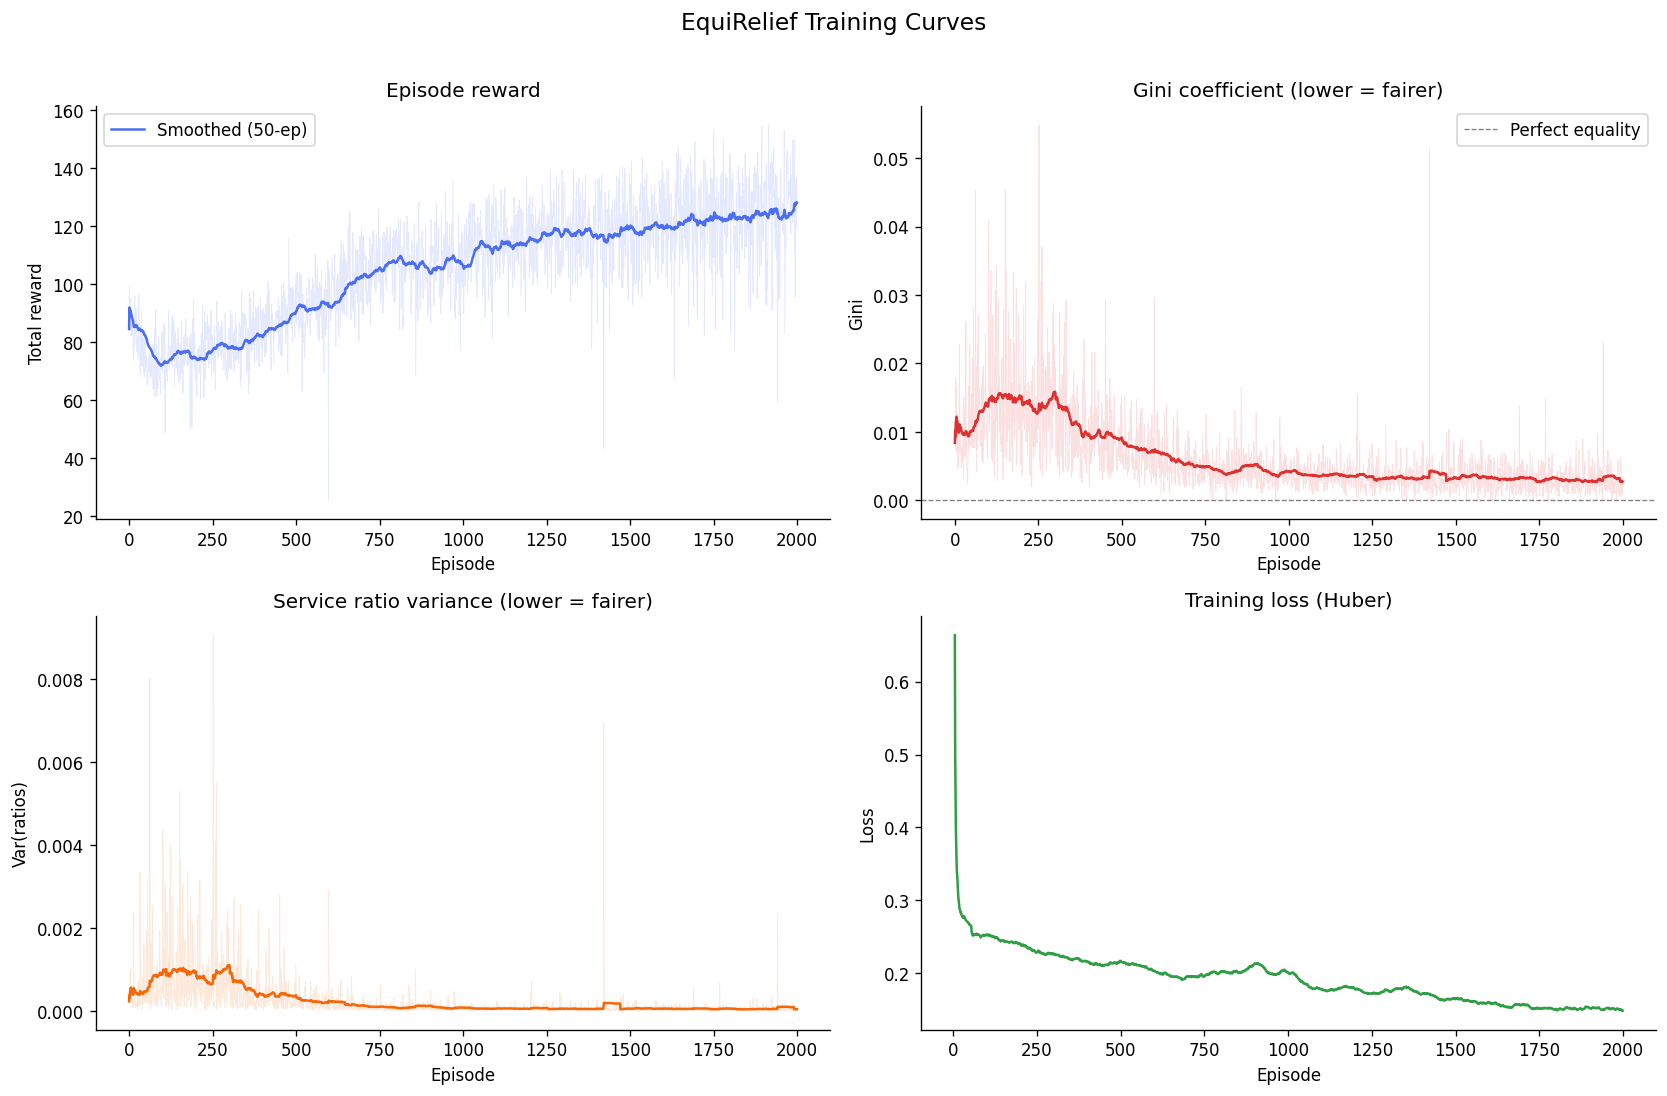


Final 100-episode averages:
  Reward  : 125.3130
  Gini    : 0.0031
  Var     : 0.00007


In [16]:
section('Training curves')

def smooth(data, window=50):
    return pd.Series(data).rolling(window, min_periods=1).mean().values

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Cumulative reward
axes[0,0].plot(smooth(ep_rewards, 50), color=C[0], linewidth=1.5, label='Smoothed (50-ep)')
axes[0,0].plot(ep_rewards, color=C[0], alpha=0.15, linewidth=0.5)
axes[0,0].set_title('Episode reward')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Total reward')
axes[0,0].legend()

# 2. Gini coefficient
axes[0,1].plot(smooth(ep_gini, 50), color=C[3], linewidth=1.5)
axes[0,1].plot(ep_gini, color=C[3], alpha=0.15, linewidth=0.5)
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=0.8, label='Perfect equality')
axes[0,1].set_title('Gini coefficient (lower = fairer)')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('Gini')
axes[0,1].legend()

# 3. Fairness variance
axes[1,0].plot(smooth(ep_fairness, 50), color=C[1], linewidth=1.5)
axes[1,0].plot(ep_fairness, color=C[1], alpha=0.15, linewidth=0.5)
axes[1,0].set_title('Service ratio variance (lower = fairer)')
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('Var(ratios)')

# 4. Training loss
if any(l > 0 for l in ep_losses):
    nonzero_losses = [(i, l) for i, l in enumerate(ep_losses) if l > 0]
    xs, ys = zip(*nonzero_losses)
    axes[1,1].plot(xs, smooth(ys, 50), color=C[2], linewidth=1.5)
    axes[1,1].set_title('Training loss (Huber)')
    axes[1,1].set_xlabel('Episode')
    axes[1,1].set_ylabel('Loss')
else:
    axes[1,1].text(0.5, 0.5, 'No loss recorded\n(warmup not complete)',
                  ha='center', va='center', transform=axes[1,1].transAxes)

plt.suptitle('EquiRelief Training Curves', fontsize=14, y=1.01)
plt.tight_layout()
savefig('rl_training_curves')
plt.show()

print(f'\nFinal 100-episode averages:')
print(f'  Reward  : {np.mean(ep_rewards[-100:]):.4f}')
print(f'  Gini    : {np.mean(ep_gini[-100:]):.4f}')
print(f'  Var     : {np.mean(ep_fairness[-100:]):.5f}')

---
# Part 11 — Policy Comparison

Compare EquiRelief against all three baselines on 100 evaluation episodes.

In [17]:
section('Policy comparison — EquiRelief vs baselines')

# Load best checkpoint
agent_eval = DoubleDQNAgent()
if os.path.exists(best_ckpt):
    agent_eval.load(best_ckpt)
    print(f'Loaded best model: {best_ckpt}')
else:
    agent_eval.online.load_state_dict(agent.online.state_dict())
    print('Using current model (best_policy.pt not found).')

def equirelief_policy(state: np.ndarray) -> int:
    return agent_eval.select_action(state, training=False)

EVAL_EPISODES = 100
all_policies = {
    'Random'         : random_policy,
    'Greedy'         : greedy_policy,
    'Equity-Greedy'  : equity_greedy_policy,
    'EquiRelief (DQN)': equirelief_policy,
}

eval_results = {}
print(f'Evaluating {EVAL_EPISODES} episodes per policy...')
for name, policy in all_policies.items():
    ep_results = [run_episode(policy, env_seed=1000+i) for i in range(EVAL_EPISODES)]
    eval_results[name] = {
        'reward'         : [r['total_reward']   for r in ep_results],
        'gini'           : [r['gini']            for r in ep_results],
        'ratio_var'      : [r['ratio_variance']  for r in ep_results],
        'mean_fairness'  : [r['mean_fairness']   for r in ep_results],
        'service_ratios' : [r['service_ratios']  for r in ep_results],
    }
    print(
        f'  {name:<20} '
        f'reward={np.mean(eval_results[name]["reward"]):>8.3f} ± {np.std(eval_results[name]["reward"]):.3f}  '
        f'gini={np.mean(eval_results[name]["gini"]):.4f}  '
        f'var={np.mean(eval_results[name]["ratio_var"]):.5f}'
    )


  Policy comparison — EquiRelief vs baselines
Loaded checkpoint from /content/drive/MyDrive/Equi-Relief/models/checkpoints/equirelief_dqn/best_policy.pt
  steps_done: 400,000  epsilon: 0.0500
Loaded best model: /content/drive/MyDrive/Equi-Relief/models/checkpoints/equirelief_dqn/best_policy.pt
Evaluating 100 episodes per policy...
  Random               reward=  91.321 ± 5.633  gini=0.0076  var=0.00025
  Greedy               reward= 150.867 ± 8.515  gini=0.0013  var=0.00001
  Equity-Greedy        reward= 150.862 ± 8.530  gini=0.0013  var=0.00001
  EquiRelief (DQN)     reward= 134.595 ± 7.593  gini=0.0024  var=0.00003



  Policy comparison — plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/rl_policy_comparison.png


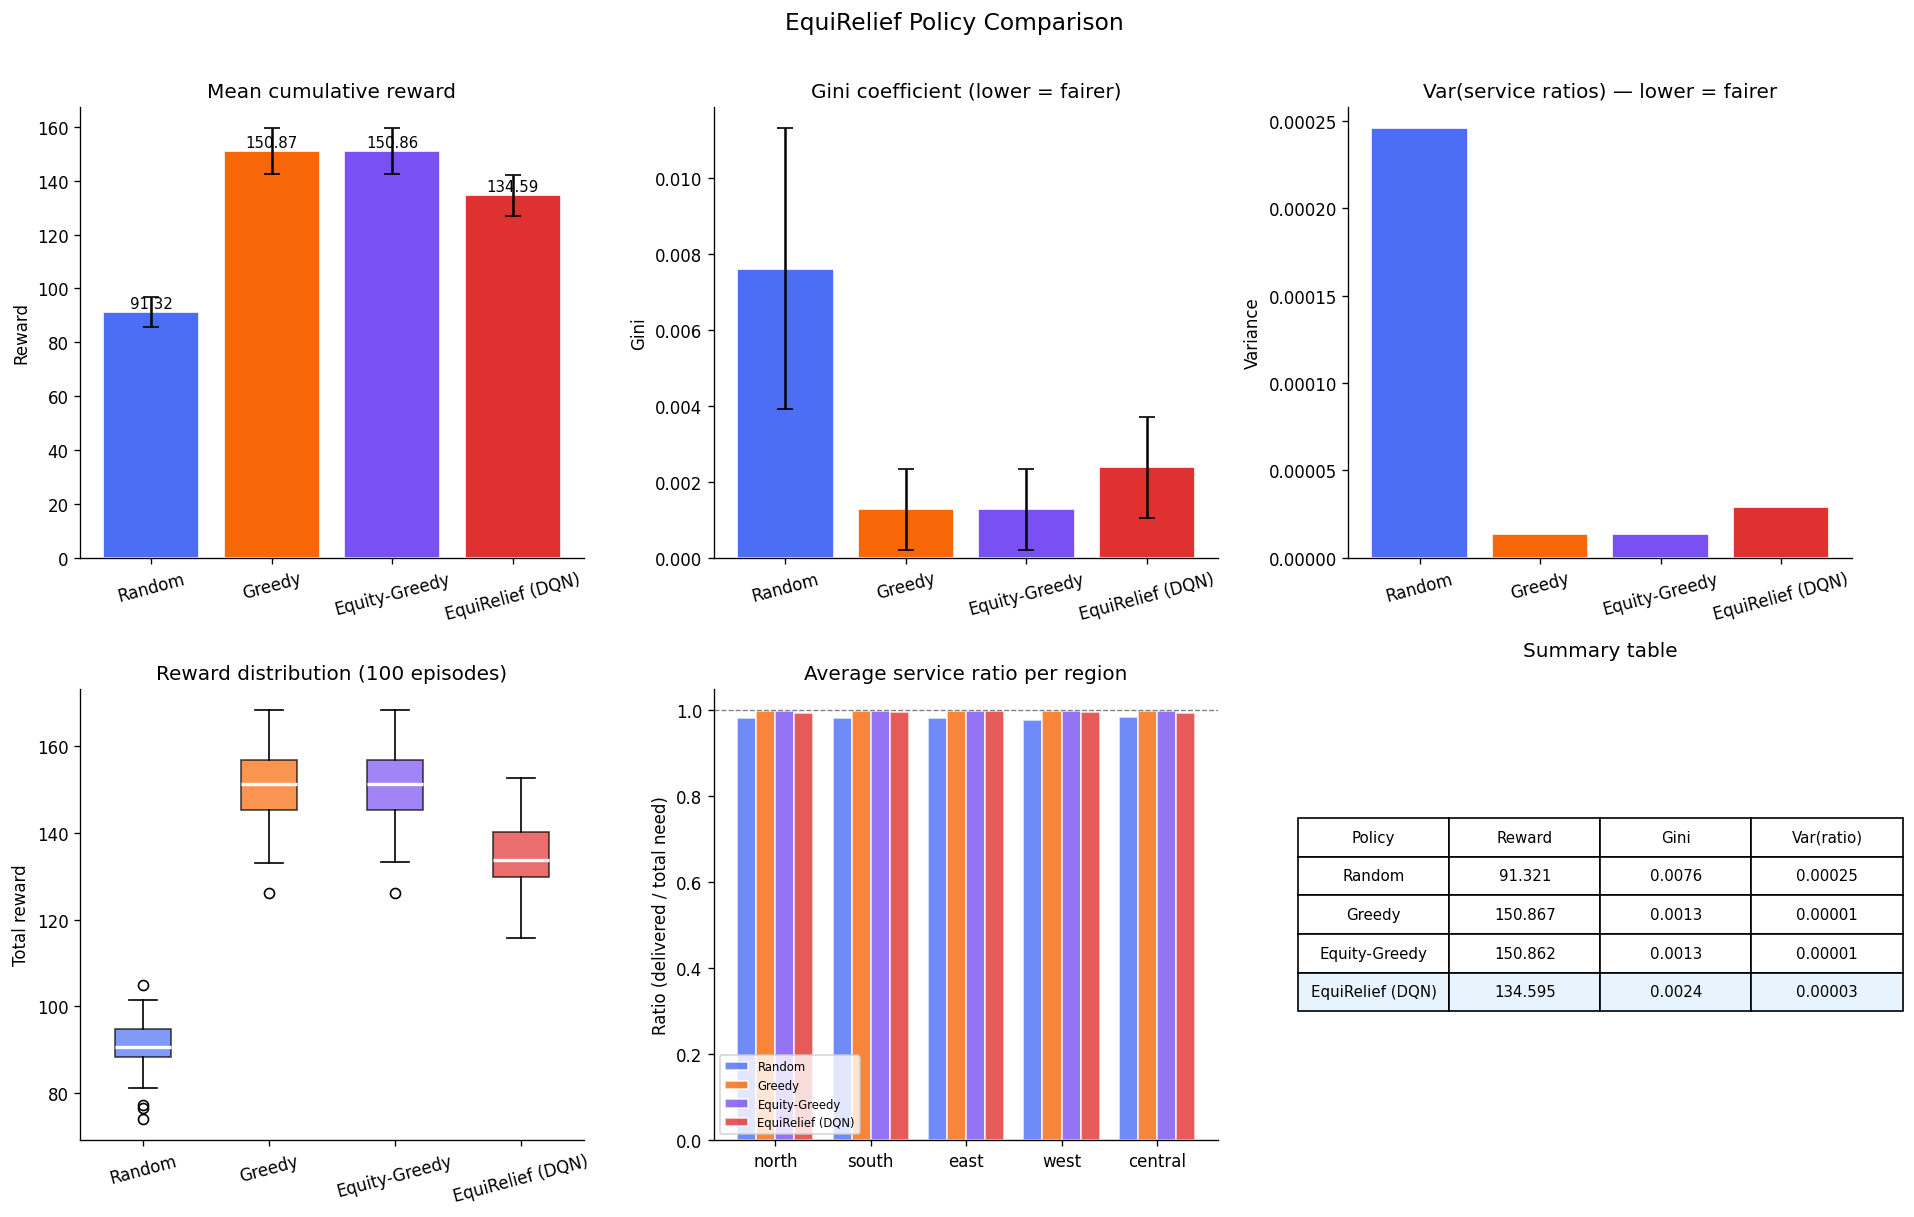

In [18]:
section('Policy comparison — plots')

policy_names = list(eval_results.keys())
colors_bar   = [C[0], C[1], C[4], C[3]]  # Random, Greedy, EqGreedy, EquiRelief

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Mean reward (bar with std)
means = [np.mean(eval_results[p]['reward'])  for p in policy_names]
stds  = [np.std(eval_results[p]['reward'])   for p in policy_names]
bars  = axes[0,0].bar(policy_names, means, color=colors_bar, yerr=stds,
                       capsize=5, edgecolor='white')
axes[0,0].set_title('Mean cumulative reward')
axes[0,0].set_ylabel('Reward')
axes[0,0].tick_params(axis='x', rotation=15)
for bar, mean in zip(bars, means):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
                   f'{mean:.2f}', ha='center', va='bottom', fontsize=9)

# 2. Gini coefficient (lower = better fairness)
means_g = [np.mean(eval_results[p]['gini']) for p in policy_names]
stds_g  = [np.std(eval_results[p]['gini'])  for p in policy_names]
axes[0,1].bar(policy_names, means_g, color=colors_bar, yerr=stds_g,
              capsize=5, edgecolor='white')
axes[0,1].set_title('Gini coefficient (lower = fairer)')
axes[0,1].set_ylabel('Gini')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Service ratio variance
means_v = [np.mean(eval_results[p]['ratio_var']) for p in policy_names]
axes[0,2].bar(policy_names, means_v, color=colors_bar, edgecolor='white')
axes[0,2].set_title('Var(service ratios) — lower = fairer')
axes[0,2].set_ylabel('Variance')
axes[0,2].tick_params(axis='x', rotation=15)

# 4. Reward distribution (box plot)
reward_data = [eval_results[p]['reward'] for p in policy_names]
bp = axes[1,0].boxplot(reward_data, labels=policy_names,
                        patch_artist=True, medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,0].set_title('Reward distribution (100 episodes)')
axes[1,0].set_ylabel('Total reward')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Per-region service ratios (final, averaged across 100 episodes)
avg_ratios = {}
for p in policy_names:
    all_ratios = eval_results[p]['service_ratios']
    avg_ratios[p] = np.mean(all_ratios, axis=0)

x = np.arange(N)
width = 0.2
for i, (p, color) in enumerate(zip(policy_names, colors_bar)):
    axes[1,1].bar(x + i*width, avg_ratios[p], width,
                  label=p, color=color, alpha=0.8, edgecolor='white')
axes[1,1].set_xticks(x + width*1.5)
axes[1,1].set_xticklabels(REGIONS)
axes[1,1].set_title('Average service ratio per region')
axes[1,1].set_ylabel('Ratio (delivered / total need)')
axes[1,1].legend(fontsize=7)
axes[1,1].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect service')

# 6. Summary table
axes[1,2].axis('off')
table_data = []
for p in policy_names:
    table_data.append([
        p,
        f"{np.mean(eval_results[p]['reward']):.3f}",
        f"{np.mean(eval_results[p]['gini']):.4f}",
        f"{np.mean(eval_results[p]['ratio_var']):.5f}",
    ])

table = axes[1,2].table(
    cellText    = table_data,
    colLabels   = ['Policy', 'Reward', 'Gini', 'Var(ratio)'],
    loc         = 'center',
    cellLoc     = 'center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
# Highlight EquiRelief row
for j in range(4):
    table[len(policy_names), j].set_facecolor('#E8F4FD')
axes[1,2].set_title('Summary table', pad=20)

plt.suptitle('EquiRelief Policy Comparison', fontsize=14, y=1.01)
plt.tight_layout()
savefig('rl_policy_comparison')
plt.show()

---
# Part 12 — Ablation Study

Test each enhancement individually to show its contribution.

In [19]:
section('Ablation study — contribution of each enhancement')

# This runs 4 shorter training runs (500 episodes each) to show
# the marginal contribution of each enhancement.
# Full training is 2000 episodes — ablation uses 500 for speed.

ABLATION_EPISODES = 500
ABLATION_EVAL     = 50

def train_agent_ablation(
    use_double_dqn : bool = True,
    use_per        : bool = True,
    use_nstep      : bool = True,
    n_episodes     : int  = ABLATION_EPISODES,
    seed           : int  = 42,
) -> List[float]:
    """
    Train a variant agent and return episode rewards.
    use_double_dqn=False: use standard DQN (target = online for selection)
    use_per=False: use uniform replay buffer
    use_nstep=False: use 1-step TD
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    agent_abl = DoubleDQNAgent(
        n_step=1 if not use_nstep else config.RL['n_step'],
    )

    # If no PER: replace with uniform buffer
    if not use_per:
        class UniformBuffer:
            def __init__(self, capacity):
                self.buf  = deque(maxlen=capacity)
                self.frame= 0
            def push(self, *args):
                self.buf.append(Transition(*args))
            def sample(self, batch_size):
                self.frame += 1
                batch = random.sample(self.buf, min(batch_size, len(self.buf)))
                return batch, None, np.ones(len(batch), dtype=np.float32)
            def update_priorities(self, *args): pass
            def __len__(self): return len(self.buf)
        agent_abl.per = UniformBuffer(config.RL['buffer_size'])

    env_abl  = EquiReliefEnv(stochastic=True)
    rewards  = []

    for ep in range(n_episodes):
        obs, _ = env_abl.reset(seed=ep)
        ep_r   = 0.0

        for step in range(MAX_STEPS):
            action = agent_abl.select_action(obs, training=True)
            obs2, reward, done, _, _ = env_abl.step(action)

            # Store transition
            if use_per:
                agent_abl.store(obs, action, reward, obs2, done)
            else:
                agent_abl.per.push(obs, action, reward, obs2, done)

            obs    = obs2
            ep_r  += reward

            total_steps = ep * MAX_STEPS + step
            if total_steps > 500 and total_steps % 4 == 0:
                # Modified learn for ablation (standard DQN variant)
                if len(agent_abl.per) >= agent_abl.batch_size:
                    transitions, indices, weights = agent_abl.per.sample(agent_abl.batch_size)
                    if transitions is None: continue

                    states      = torch.tensor(np.stack([t.state for t in transitions]),
                                               dtype=torch.float32, device=agent_abl.device)
                    actions_t   = torch.tensor([t.action for t in transitions],
                                               dtype=torch.long, device=agent_abl.device)
                    rewards_t   = torch.tensor([t.reward for t in transitions],
                                               dtype=torch.float32, device=agent_abl.device)
                    next_states = torch.tensor(np.stack([t.next_state for t in transitions]),
                                               dtype=torch.float32, device=agent_abl.device)
                    dones_t     = torch.tensor([t.done for t in transitions],
                                               dtype=torch.float32, device=agent_abl.device)
                    is_w        = torch.tensor(weights, dtype=torch.float32,
                                               device=agent_abl.device)

                    q_curr = agent_abl.online(states).gather(
                        1, actions_t.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        if use_double_dqn:
                            best_a = agent_abl.online(next_states).argmax(dim=1)
                            q_next = agent_abl.target(next_states).gather(
                                1, best_a.unsqueeze(1)).squeeze(1)
                        else:
                            # Standard DQN: target network selects AND evaluates
                            q_next = agent_abl.target(next_states).max(dim=1)[0]

                        n = agent_abl.n_step
                        q_tgt = rewards_t + (agent_abl.gamma ** n) * q_next * (1 - dones_t)

                    td_err = (q_tgt - q_curr).detach().cpu().numpy()
                    loss   = (is_w * F.huber_loss(q_curr, q_tgt, reduction='none')).mean()

                    agent_abl.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(agent_abl.online.parameters(), 10.0)
                    agent_abl.optimizer.step()

                    if use_per and indices is not None:
                        agent_abl.per.update_priorities(indices, td_err)

                    if total_steps % agent_abl.target_update == 0:
                        agent_abl.target.load_state_dict(agent_abl.online.state_dict())

            if done: break

        rewards.append(ep_r)

    return rewards


print('Running ablation study (4 variants × 500 episodes each)...')
print('Estimated time: ~8-10 minutes')

ablation_configs = [
    ('Standard DQN',              False, False, False),
    ('+ Double DQN',              True,  False, False),
    ('+ Double DQN + PER',        True,  True,  False),
    ('Full EquiRelief',           True,  True,  True),
]

ablation_rewards = {}
for name, use_ddqn, use_per, use_ns in ablation_configs:
    t0 = time.time()
    rewards = train_agent_ablation(
        use_double_dqn=use_ddqn,
        use_per=use_per,
        use_nstep=use_ns,
        n_episodes=ABLATION_EPISODES
    )
    ablation_rewards[name] = rewards
    print(f'  {name:<35} final mean reward: {np.mean(rewards[-100:]):.4f}  ({time.time()-t0:.0f}s)')


  Ablation study — contribution of each enhancement
Running ablation study (4 variants × 500 episodes each)...
Estimated time: ~8-10 minutes
  Standard DQN                        final mean reward: 90.8048  (227s)
  + Double DQN                        final mean reward: 85.7475  (243s)
  + Double DQN + PER                  final mean reward: 75.5970  (294s)
  Full EquiRelief                     final mean reward: 80.6612  (296s)



  Ablation study — plot
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/rl_ablation_study.png


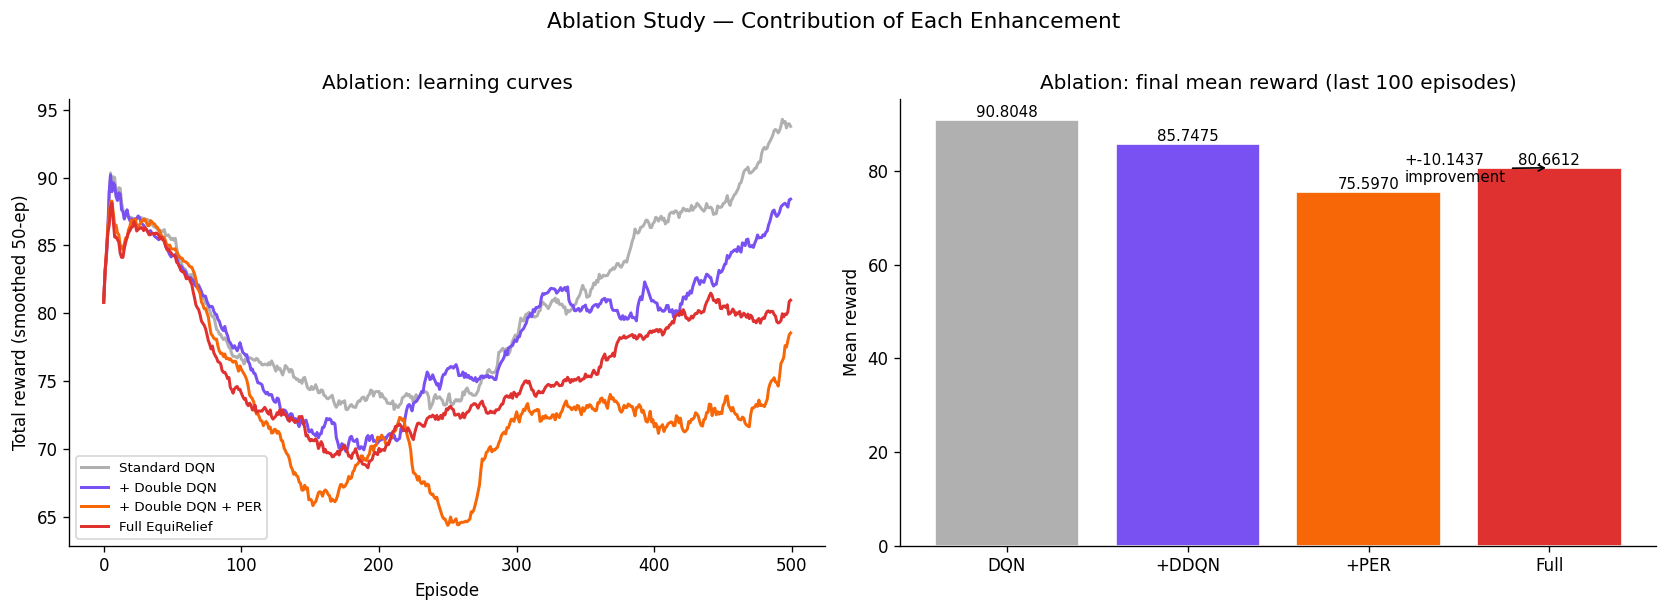


Contribution of each enhancement:
  Standard DQN                         90.8048  (baseline)
  + Double DQN                         85.7475  (baseline)
  + Double DQN + PER                   75.5970  (baseline)
  Full EquiRelief                      80.6612  (+5.0642)+


In [20]:
section('Ablation study — plot')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ablation_colors = ['#B0B0B0', '#7950F2', '#F76707', '#E03131']

# Learning curves
for (name, _, _, _), color in zip(ablation_configs, ablation_colors):
    r = ablation_rewards[name]
    axes[0].plot(smooth(r, 50), label=name, color=color, linewidth=1.8)
axes[0].set_title('Ablation: learning curves')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward (smoothed 50-ep)')
axes[0].legend(fontsize=8)

# Final performance bar
final_means = [
    np.mean(ablation_rewards[name][-100:])
    for name, _, _, _ in ablation_configs
]
names_short = ['DQN', '+DDQN', '+PER', 'Full']
bars = axes[1].bar(names_short, final_means, color=ablation_colors, edgecolor='white')
axes[1].set_title('Ablation: final mean reward (last 100 episodes)')
axes[1].set_ylabel('Mean reward')
for bar, val in zip(bars, final_means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Annotate improvement
improvement = final_means[-1] - final_means[0]
axes[1].annotate(
    f'+{improvement:.4f}\nimprovement',
    xy=(3, final_means[-1]),
    xytext=(2.2, final_means[-1] - abs(improvement)*0.3),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.suptitle('Ablation Study — Contribution of Each Enhancement', fontsize=13, y=1.01)
plt.tight_layout()
savefig('rl_ablation_study')
plt.show()

print('\nContribution of each enhancement:')
for i, (name, _, _, _) in enumerate(ablation_configs):
    delta = final_means[i] - final_means[i-1] if i > 0 else 0
    print(f'  {name:<35} {final_means[i]:>8.4f}  {"(+"+f"{delta:.4f})+" if delta > 0 else "(baseline)"}')

---
# Part 13 — Fairness Deep Dive

Visualise how each policy treats individual regions over time.


  Fairness deep dive — per-region service ratios over time
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/rl_fairness_deep_dive.png


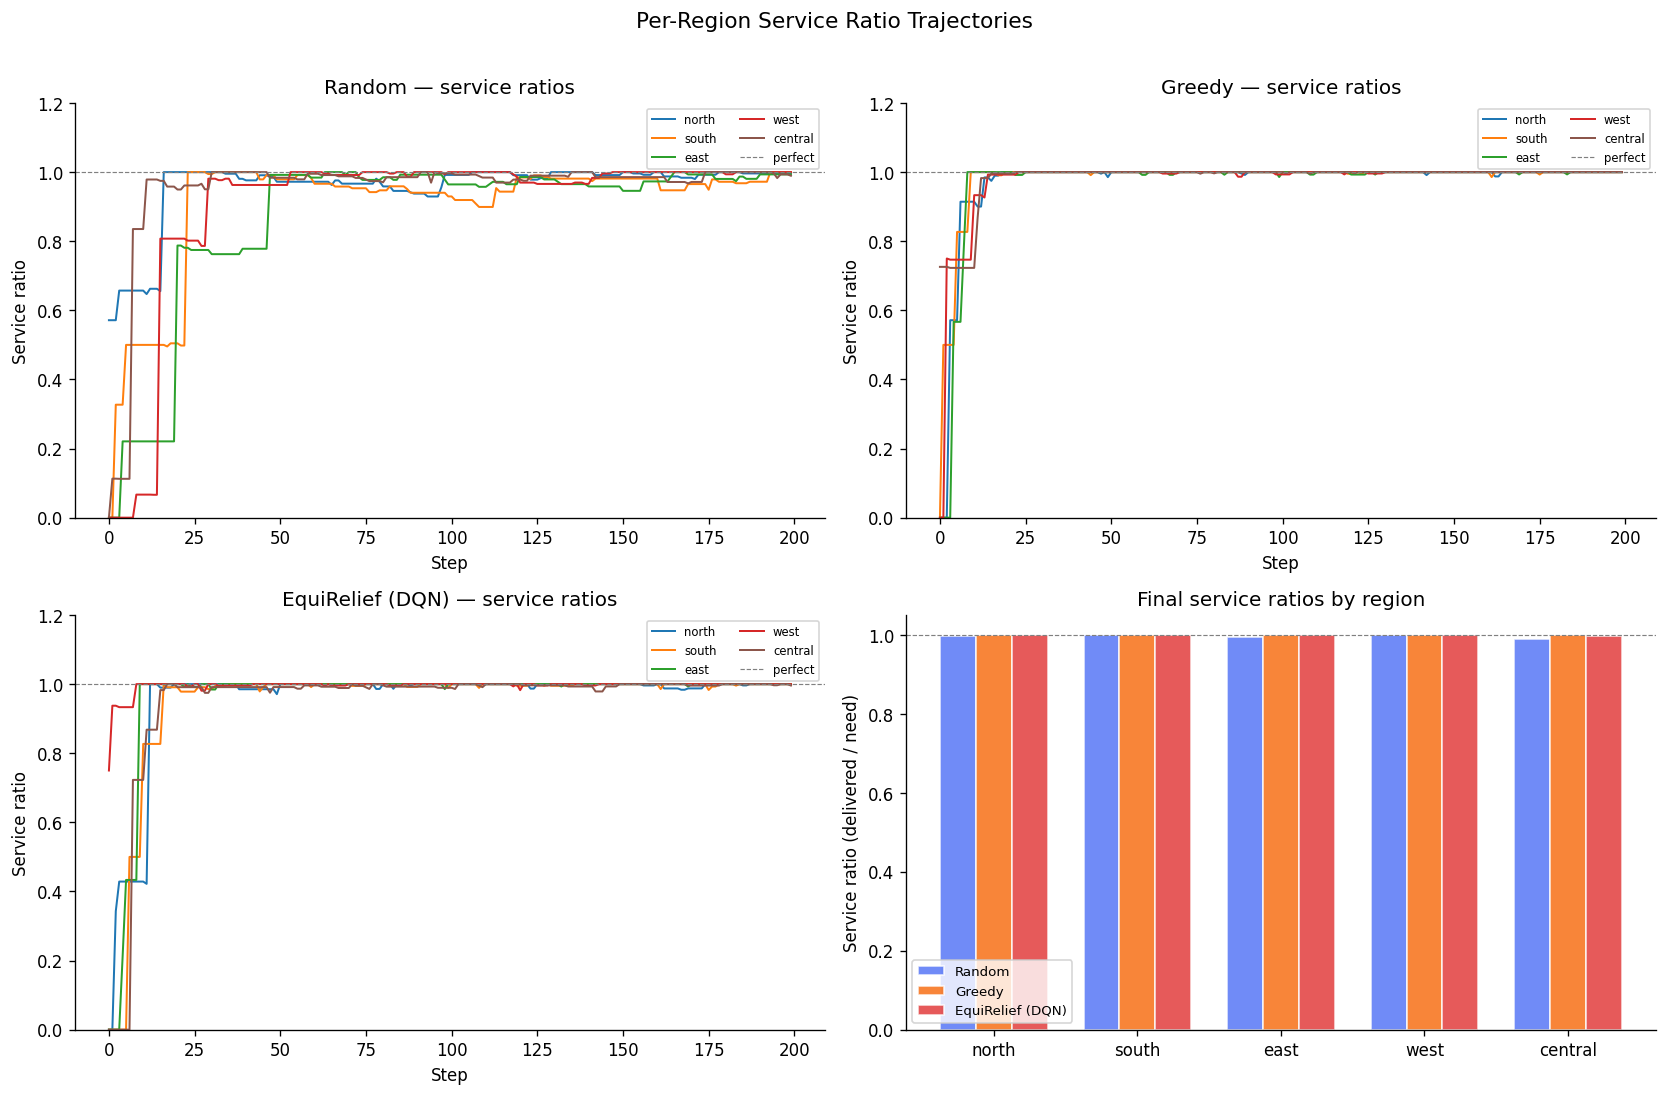


Region                    Random                Greedy      EquiRelief (DQN)
---------------------------------------------------------------------------
north                     0.9962                1.0000                1.0000
south                     1.0000                1.0000                1.0000
east                      0.9934                1.0000                1.0000
west                      1.0000                1.0000                1.0000
central                   0.9895                1.0000                0.9959

Gini coefficients:
  Random                    Gini=0.0022
  Greedy                    Gini=0.0000
  EquiRelief (DQN)          Gini=0.0007


In [21]:
section('Fairness deep dive — per-region service ratios over time')

def run_episode_detailed(policy_fn, env_seed=999) -> dict:
    """Run one episode and record per-region ratios at every step."""
    env  = EquiReliefEnv(stochastic=True, seed=env_seed)
    obs, _ = env.reset(seed=env_seed)
    ratio_history = [[] for _ in range(N)]  # per region
    action_history= []

    for _ in range(MAX_STEPS):
        action = policy_fn(obs)
        obs, _, done, _, info = env.step(action)
        for i in range(N):
            ratio_history[i].append(info['ratios'][i])
        action_history.append(action)
        if done: break

    return {
        'ratio_history' : ratio_history,
        'action_history': action_history,
        'final_ratios'  : [r[-1] for r in ratio_history],
    }


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

compare_policies = {
    'Random'          : (random_policy, C[0]),
    'Greedy'          : (greedy_policy, C[1]),
    'EquiRelief (DQN)': (equirelief_policy, C[3]),
}

detailed_results = {}
for name, (policy, _) in compare_policies.items():
    detailed_results[name] = run_episode_detailed(policy)

# 1-3. Service ratio trajectories per policy
plot_pairs = [
    ('Random', axes[0,0]),
    ('Greedy', axes[0,1]),
    ('EquiRelief (DQN)', axes[1,0]),
]
region_colors = plt.cm.tab10(np.linspace(0, 0.5, N))
for policy_name, ax in plot_pairs:
    res = detailed_results[policy_name]
    for i, (region, color) in enumerate(zip(REGIONS, region_colors)):
        ax.plot(res['ratio_history'][i], label=region, color=color, linewidth=1.2)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7, label='perfect')
    ax.set_title(f'{policy_name} — service ratios')
    ax.set_xlabel('Step')
    ax.set_ylabel('Service ratio')
    ax.legend(fontsize=7, ncol=2)
    ax.set_ylim(0, 1.2)

# 4. Final ratio radar / bar comparison
ax = axes[1,1]
x  = np.arange(N)
w  = 0.25
for i, (name, (_, color)) in enumerate(compare_policies.items()):
    ax.bar(x + i*w, detailed_results[name]['final_ratios'],
           w, label=name, color=color, alpha=0.8, edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels(REGIONS)
ax.set_title('Final service ratios by region')
ax.set_ylabel('Service ratio (delivered / need)')
ax.legend(fontsize=8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)

plt.suptitle('Per-Region Service Ratio Trajectories', fontsize=13, y=1.01)
plt.tight_layout()
savefig('rl_fairness_deep_dive')
plt.show()

# Print final ratios
print(f'\n{"Region":<10}', end='')
for name in compare_policies:
    print(f'{name:>22}', end='')
print()
print('-' * 75)
for i, region in enumerate(REGIONS):
    print(f'{region:<10}', end='')
    for name in compare_policies:
        print(f'{detailed_results[name]["final_ratios"][i]:>22.4f}', end='')
    print()

print('\nGini coefficients:')
for name in compare_policies:
    gini_val = utils.gini(detailed_results[name]['final_ratios'])
    print(f'  {name:<25} Gini={gini_val:.4f}')

---
# Part 14 — Urgency Response Analysis

Does EquiRelief respond faster to urgent regions?


  Urgency response analysis
Testing urgency response...
  Random                    mean_response=   3.3 steps  immediate=42.0%  within_5=74.0%  served_first=20.0%
  Greedy                    mean_response=   0.0 steps  immediate=100.0%  within_5=100.0%  served_first=100.0%
  EquiRelief (DQN)          mean_response=   2.0 steps  immediate= 0.0%  within_5=100.0%  served_first= 0.0%
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/rl_urgency_response.png


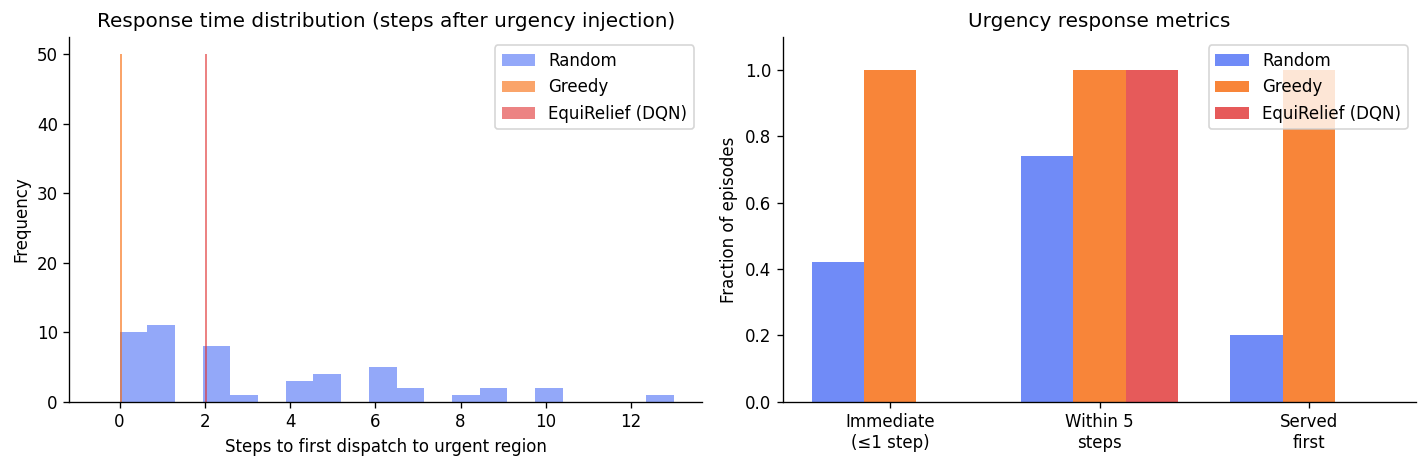

In [22]:
section('Urgency response analysis')

def urgency_response_test(policy_fn, n_episodes=50) -> dict:
    """
    Inject a high-urgency event mid-episode and measure
    how quickly the policy responds (steps to first dispatch).
    """
    response_steps = []   # steps until urgent region first served
    served_first   = []   # was the urgent region served before others?

    for ep in range(n_episodes):
        env  = EquiReliefEnv(stochastic=False, seed=ep)
        obs, _ = env.reset(seed=ep)

        # Inject high-urgency event at step 10 in region 0 (north)
        urgent_region = 0
        inject_step   = 10
        responded     = False
        response_step = MAX_STEPS  # worst case = never responded
        other_dispatches_before = 0

        for step in range(MAX_STEPS):
            if step == inject_step:
                # Inject: set north urgency to 1.0, high food need
                env.urgency[urgent_region] = 1.0
                env.need[urgent_region, 0] = 0.9  # high food need
                obs = env._get_state()

            action = policy_fn(obs)
            obs, _, done, _, _ = env.step(action)

            if step >= inject_step and not responded:
                res_i, reg_i = action // N, action % N
                if reg_i != urgent_region and action != N_ACTIONS - 1:
                    other_dispatches_before += 1
                if reg_i == urgent_region:
                    response_step = step - inject_step
                    responded     = True

            if done: break

        response_steps.append(response_step)
        served_first.append(other_dispatches_before == 0 and responded)

    return {
        'mean_response_steps': np.mean(response_steps),
        'median_response'    : np.median(response_steps),
        'pct_immediate'      : np.mean(np.array(response_steps) <= 1),
        'pct_within_5'       : np.mean(np.array(response_steps) <= 5),
        'pct_served_first'   : np.mean(served_first),
        'response_steps'     : response_steps,
    }


print('Testing urgency response...')
urgency_results = {}
for name, (policy, color) in compare_policies.items():
    urgency_results[name] = urgency_response_test(policy, n_episodes=50)
    r = urgency_results[name]
    print(
        f'  {name:<25} '
        f'mean_response={r["mean_response_steps"]:>6.1f} steps  '
        f'immediate={r["pct_immediate"]:>5.1%}  '
        f'within_5={r["pct_within_5"]:>5.1%}  '
        f'served_first={r["pct_served_first"]:>5.1%}'
    )

# Plot response time distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, (_, color) in compare_policies.items():
    axes[0].hist(
        urgency_results[name]['response_steps'],
        bins=20, alpha=0.6, label=name, color=color
    )
axes[0].set_title('Response time distribution (steps after urgency injection)')
axes[0].set_xlabel('Steps to first dispatch to urgent region')
axes[0].set_ylabel('Frequency')
axes[0].legend()

metrics = ['pct_immediate','pct_within_5','pct_served_first']
metric_labels = ['Immediate\n(≤1 step)', 'Within 5\nsteps', 'Served\nfirst']
x  = np.arange(len(metrics))
w  = 0.25
for i, (name, (_, color)) in enumerate(compare_policies.items()):
    vals = [urgency_results[name][m] for m in metrics]
    axes[1].bar(x + i*w, vals, w, label=name, color=color, alpha=0.8)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(metric_labels)
axes[1].set_title('Urgency response metrics')
axes[1].set_ylabel('Fraction of episodes')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.tight_layout()
savefig('rl_urgency_response')
plt.show()

---
# Part 15 — Save Final Results & Week 3 Summary

In [23]:
section('Save final results')

# Build results dict
results = {
    'training': {
        'n_episodes'       : TRAIN_CFG['n_episodes'],
        'final_mean_reward': float(np.mean(ep_rewards[-100:])),
        'final_mean_gini'  : float(np.mean(ep_gini[-100:])),
        'final_mean_var'   : float(np.mean(ep_fairness[-100:])),
        'best_reward'      : float(best_reward),
    },
    'policy_comparison': {
        name: {
            'mean_reward'   : float(np.mean(eval_results[name]['reward'])),
            'std_reward'    : float(np.std(eval_results[name]['reward'])),
            'mean_gini'     : float(np.mean(eval_results[name]['gini'])),
            'mean_ratio_var': float(np.mean(eval_results[name]['ratio_var'])),
        }
        for name in eval_results
    },
    'ablation': {
        name: {
            'final_mean_reward': float(np.mean(ablation_rewards[name][-100:]))
        }
        for name, _, _, _ in ablation_configs
    },
    'urgency_response': {
        name: {
            'mean_response_steps': float(urgency_results[name]['mean_response_steps']),
            'pct_immediate'      : float(urgency_results[name]['pct_immediate']),
            'pct_within_5'       : float(urgency_results[name]['pct_within_5']),
            'pct_served_first'   : float(urgency_results[name]['pct_served_first']),
        }
        for name in urgency_results
    },
    'config': TRAIN_CFG,
}

results_path = f'{config.OUT_RESULTS}/rl_results.json'
utils.save_json(results, results_path)
print(f'Results saved -> {results_path}')

# Save training curves as CSV for Week 4 plotting
curves_df = pd.DataFrame({
    'episode'  : range(len(ep_rewards)),
    'reward'   : ep_rewards,
    'gini'     : ep_gini,
    'fairness_var': ep_fairness,
    'loss'     : ep_losses,
})
curves_path = f'{config.OUT_RESULTS}/training_curves.csv'
curves_df.to_csv(curves_path, index=False)
print(f'Training curves saved -> {curves_path}')


section('Week 3 complete — deliverables checklist')

deliverables = [
    (best_ckpt,                               'Best policy checkpoint'),
    (latest_ckpt,                             'Latest checkpoint'),
    (results_path,                            'RL results JSON'),
    (curves_path,                             'Training curves CSV'),
    (f'{config.OUT_PLOTS}/rl_training_curves.png',    'Training curves plot'),
    (f'{config.OUT_PLOTS}/rl_policy_comparison.png',  'Policy comparison plot'),
    (f'{config.OUT_PLOTS}/rl_ablation_study.png',     'Ablation study plot'),
    (f'{config.OUT_PLOTS}/rl_fairness_deep_dive.png', 'Fairness deep dive plot'),
    (f'{config.OUT_PLOTS}/rl_urgency_response.png',   'Urgency response plot'),
]

all_ok = True
for path, desc in deliverables:
    exists = os.path.exists(path)
    if not exists: all_ok = False
    status = 'OK' if exists else 'MISSING'
    size   = f' ({os.path.getsize(path)/1e3:.0f} KB)' if exists else ''
    print(f'  [{status}]  {desc}{size}')

print()
if all_ok:
    print('All deliverables present.')
    print('Ready for Week 4 — Evaluation & Demo.')
else:
    print('Some files missing — re-run relevant cells.')

print('\nKey results summary:')
print(f'  EquiRelief mean reward : {results["policy_comparison"]["EquiRelief (DQN)"]["mean_reward"]:.4f}')
print(f'  Greedy mean reward     : {results["policy_comparison"]["Greedy"]["mean_reward"]:.4f}')
print(f'  EquiRelief Gini        : {results["policy_comparison"]["EquiRelief (DQN)"]["mean_gini"]:.4f}')
print(f'  Greedy Gini            : {results["policy_comparison"]["Greedy"]["mean_gini"]:.4f}')


  Save final results
Saved -> /content/drive/MyDrive/Equi-Relief/outputs/results/rl_results.json
Results saved -> /content/drive/MyDrive/Equi-Relief/outputs/results/rl_results.json
Training curves saved -> /content/drive/MyDrive/Equi-Relief/outputs/results/training_curves.csv

  Week 3 complete — deliverables checklist
  [OK]  Best policy checkpoint (3223 KB)
  [OK]  Latest checkpoint (3218 KB)
  [OK]  RL results JSON (2 KB)
  [OK]  Training curves CSV (155 KB)
  [OK]  Training curves plot (238 KB)
  [OK]  Policy comparison plot (216 KB)
  [OK]  Ablation study plot (172 KB)
  [OK]  Fairness deep dive plot (196 KB)
  [OK]  Urgency response plot (69 KB)

All deliverables present.
Ready for Week 4 — Evaluation & Demo.

Key results summary:
  EquiRelief mean reward : 134.5946
  Greedy mean reward     : 150.8671
  EquiRelief Gini        : 0.0024
  Greedy Gini            : 0.0013


In [24]:
# Diagnostic — run this immediately
print(f'ep_rewards length : {len(ep_rewards)}')
print(f'ep_gini length    : {len(ep_gini)}')
print(f'First reward      : {ep_rewards[0] if ep_rewards else "EMPTY"}')
print(f'Last reward       : {ep_rewards[-1] if ep_rewards else "EMPTY"}')
print(f'Mean last 100     : {np.mean(ep_rewards[-100:]) if len(ep_rewards) >= 100 else "NOT ENOUGH DATA"}')

ep_rewards length : 2000
ep_gini length    : 2000
First reward      : 84.44203186035156
Last reward       : 118.45370483398438
Mean last 100     : 125.31299591064453
